In [1]:
# Bootstrap: agrega la raíz del repo al path e importa init_agents
# (carga .env y configura la key de tracing de OpenAI)
import sys, pathlib
_root = pathlib.Path.cwd()
while not (_root / "init_agents.py").exists() and _root != _root.parent:
    _root = _root.parent
sys.path.append(str(_root))
import init_agents

## Semana 4 Día 4 - ¡preparando el gran proyecto!
 
# El Compañero

Es hora de presentar:

1. Salidas estructuradas
2. Un flujo multi-agente

In [2]:
from typing import Annotated, TypedDict, List, Dict, Any, Optional
from typing_extensions import TypedDict
from langchain_core.messages import AIMessage, HumanMessage, SystemMessage
from langchain_openai import ChatOpenAI
from langchain_community.agent_toolkits import PlayWrightBrowserToolkit
from langchain_community.tools.playwright.utils import create_async_playwright_browser
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.graph.message import add_messages
from pydantic import BaseModel, Field
from IPython.display import Image, display
import gradio as gr
import uuid
from dotenv import load_dotenv

In [3]:
load_dotenv(override=True)

True

### Para salidas estructuradas, definimos un objeto Pydantic para el esquema

In [4]:
# Primero definimos la salida estructurada

class EvaluatorOutput(BaseModel):
    feedback: str = Field(description="Comentarios sobre la respuesta del asistente")
    success_criteria_met: bool = Field(description="Si se han cumplido los criterios de éxito")
    user_input_needed: bool = Field(description="Verdadero si se necesita más información del usuario, o aclaraciones, o el asistente está bloqueado.")


### Y para el Estado, usaremos TypedDict nuevamente
 
¡Pero ahora tenemos información real que mantener!

Los mensajes usan el reductor. Los otros son simplemente valores que sobrescribimos con cualquier cambio de estado.

In [5]:
# The state

class State(TypedDict):
    messages: Annotated[List[Any], add_messages]
    success_criteria: str
    feedback_on_work: Optional[str]
    success_criteria_met: bool
    user_input_needed: bool

In [6]:
import nest_asyncio
import uvloop
import asyncio

nest_asyncio.apply()

# Parche de uvloop: evita RuntimeError en threads nuevos (Gradio workers)
original_get_event_loop = uvloop.EventLoopPolicy.get_event_loop

def patched_get_event_loop(self):
    try:
        return original_get_event_loop(self)
    except RuntimeError:
        loop = self.new_event_loop()
        self.set_event_loop(loop)
        return loop

uvloop.EventLoopPolicy.get_event_loop = patched_get_event_loop

async_browser = create_async_playwright_browser(headless=False)
toolkit = PlayWrightBrowserToolkit.from_browser(async_browser=async_browser)
tools = toolkit.get_tools()

In [7]:
# Inicializamos los LLMs

worker_llm = ChatOpenAI(model="gpt-4o-mini")
worker_llm_with_tools = worker_llm.bind_tools(tools)

evaluator_llm = ChatOpenAI(model="gpt-4o-mini")
evaluator_llm_with_output = evaluator_llm.with_structured_output(EvaluatorOutput)

In [8]:
# El nodo trabajador

def worker(state: State) -> Dict[str, Any]:
    system_message = f"""Eres un asistente útil que puede usar herramientas para completar tareas.
Continúas trabajando en una tarea hasta que tengas una pregunta o aclaración para el usuario, o hasta que se cumplan los criterios de éxito.
Estos son los criterios de éxito:
{state['success_criteria']}
Debes responder con una pregunta para el usuario sobre esta tarea o con tu respuesta final.
Si tienes una pregunta para el usuario, debes responderla claramente. Un ejemplo podría ser:

Pregunta: por favor, aclara si deseas un resumen o una respuesta detallada.

Si has terminado, responde con la respuesta final y no hagas ninguna pregunta; simplemente responde con la respuesta.
"""
    
    if state.get("feedback_on_work"):
        system_message += f"""
Anteriormente creías haber completado la tarea, pero tu respuesta fue rechazada porque no cumplía los criterios de éxito.
Aquí tienes la explicación del motivo del rechazo:
{state['feedback_on_work']}
Con esta información, continúa con la tarea y asegúrate de que cumples los criterios de éxito o si tienes alguna pregunta para el usuario."""
    
    # Añadir el mensaje del sistema

    found_system_message = False
    messages = state["messages"]
    for message in messages:
        if isinstance(message, SystemMessage):
            message.content = system_message
            found_system_message = True
    
    if not found_system_message:
        messages = [SystemMessage(content=system_message)] + messages
    
    # Invocar el LLM con herramientas
    response = worker_llm_with_tools.invoke(messages)
    
    # Retornar el estado actualizado
    return {
        "messages": [response],
    }

In [9]:
def worker_router(state: State) -> str:
    last_message = state["messages"][-1]
    
    if hasattr(last_message, "tool_calls") and last_message.tool_calls:
        return "tools"
    else:
        return "evaluator"

In [10]:
def format_conversation(messages: List[Any]) -> str:
    conversation = "Historial de la conversación:\n\n"
    for message in messages:
        if isinstance(message, HumanMessage):
            conversation += f"Usuario: {message.content}\n"
        elif isinstance(message, AIMessage):
            text = message.content or "[Herramienta usada]"
            conversation += f"Asistente: {text}\n"
    return conversation

In [11]:
def evaluator(state: State) -> State:
    last_response = state["messages"][-1].content

    system_message = f"""Eres el evaluador que determina si un asistente ha completado una tarea correctamente.
Evalúa la última respuesta del asistente según los criterios establecidos. Responde con tus comentarios y tu decisión 
sobre si se han cumplido los criterios de éxito y si se necesita más información del usuario."""
    
    user_message = f"""Estás evaluando una conversación entre el usuario y el asistente. Decide qué acción tomar según la 
última respuesta del asistente.

La conversación completa con el asistente, con la solicitud original del usuario y todas las respuestas, es:
{format_conversation(state['messages'])}

Los criterios de éxito para esta tarea son:
{state['success_criteria']}

Y la respuesta final del Asistente que estás evaluando es:
{last_response}

Responde con tus comentarios y decide si esta respuesta cumple con los criterios de éxito.
Además, decide si se requiere más participación del usuario, ya sea porque el asistente tiene una pregunta, 
necesita una aclaración o parece estar bloqueado y no puede responder sin ayuda."""
    
    if state["feedback_on_work"]:
        user_message += f"Además, tenga en cuenta que en un intento anterior del Asistente, proporcionó estos comentarios: {state['feedback_on_work']}\n"
        user_message += "Si ves que el Asistente repite los mismos errores, considera responder que se requiere la intervención del usuario."
    
    evaluator_messages = [SystemMessage(content=system_message), HumanMessage(content=user_message)]

    eval_result = evaluator_llm_with_output.invoke(evaluator_messages)
    new_state = {
        "messages": [{"role": "assistant", "content": f"Comentarios del evaluador sobre esta respuesta: {eval_result.feedback}"}],
        "feedback_on_work": eval_result.feedback,
        "success_criteria_met": eval_result.success_criteria_met,
        "user_input_needed": eval_result.user_input_needed
    }
    return new_state

In [12]:
def route_based_on_evaluation(state: State) -> str:
    if state["success_criteria_met"] or state["user_input_needed"]:
        return "END"
    else:
        return "worker"

In [13]:
# Set up Graph Builder with State
graph_builder = StateGraph(State)

# Add nodes
graph_builder.add_node("worker", worker)
graph_builder.add_node("tools", ToolNode(tools=tools))
graph_builder.add_node("evaluator", evaluator)

# Add edges
graph_builder.add_conditional_edges("worker", worker_router, {"tools": "tools", "evaluator": "evaluator"})
graph_builder.add_edge("tools", "worker")
graph_builder.add_conditional_edges("evaluator", route_based_on_evaluation, {"worker": "worker", "END": END})
graph_builder.add_edge(START, "worker")

# Compile the graph
memory = MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

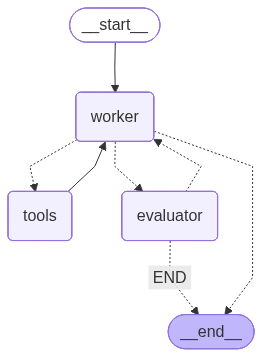

In [14]:
display(Image(graph.get_graph().draw_mermaid_png()))

### A continuación viene el Callback de gradio para iniciar un súper paso.

In [15]:
def make_thread_id() -> str:
    return str(uuid.uuid4())


async def process_message(message, success_criteria, history, thread):

    config = {"configurable": {"thread_id": thread}}

    state = {
        "messages": message,
        "success_criteria": success_criteria,
        "feedback_on_work": None,
        "success_criteria_met": False,
        "user_input_needed": False
    }
    result = await graph.ainvoke(state, config=config)
    user = {"role": "user", "content": message}
    reply = {"role": "assistant", "content": result["messages"][-2].content}
    feedback = {"role": "assistant", "content": result["messages"][-1].content}
    return history + [user, reply, feedback]

async def reset():
    return "", "", None, make_thread_id()



### Y ahora lanzamos la Sidekick UI

In [16]:

with gr.Blocks(theme=gr.themes.Default(primary_hue="emerald")) as demo:
    gr.Markdown("## Compañero de trabajo personal Sidekick")
    thread = gr.State(make_thread_id())
    
    with gr.Row():
        chatbot = gr.Chatbot(label="Sidekick", height=300, type="messages")
    with gr.Group():
        with gr.Row():
            message = gr.Textbox(show_label=False, placeholder="Tu solicitud a tu compañero")
        with gr.Row():
            success_criteria = gr.Textbox(show_label=False, placeholder="¿Cuáles son tus criterios de éxito?")
    with gr.Row():
        reset_button = gr.Button("Reiniciar", variant="stop")
        go_button = gr.Button("Ir!", variant="primary")
    message.submit(process_message, [message, success_criteria, chatbot, thread], [chatbot])
    success_criteria.submit(process_message, [message, success_criteria, chatbot, thread], [chatbot])
    go_button.click(process_message, [message, success_criteria, chatbot, thread], [chatbot])
    reset_button.click(reset, [], [message, success_criteria, chatbot, thread])

    
demo.launch()

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


Traceback (most recent call last):
  File "/home/jp/agents/.venv/lib/python3.12/site-packages/gradio/queueing.py", line 625, in process_events
    response = await route_utils.call_process_api(
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/jp/agents/.venv/lib/python3.12/site-packages/gradio/route_utils.py", line 322, in call_process_api
    output = await app.get_blocks().process_api(
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/jp/agents/.venv/lib/python3.12/site-packages/gradio/blocks.py", line 2191, in process_api
    result = await self.call_function(
             ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/jp/agents/.venv/lib/python3.12/site-packages/gradio/blocks.py", line 1700, in call_function
    prediction = await fn(*processed_input)
                 ^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/jp/agents/.venv/lib/python3.12/site-packages/gradio/utils.py", line 861, in async_wrapper
    response = await f(*args, **kwargs)
               ^^^^^^^^^

<table style="margin: 0; text-align: left; width:100%">
    <tr>
        <td style="width: 150px; height: 150px; vertical-align: middle;">
            <img src="../assets/thanks.png" width="150" height="150" style="display: block;" />
        </td>
        <td>
            <h2 style="color:#00cc00;">¡Felicidades por crear la primera versión de Sidekick!</h2>
<span style="color:#00cc00;">Este es un momento épico del curso. Has dado el comienzo de algo muy potente. Y has mejorado tus habilidades con un impresionante framework de agentes en LangGraph. Quizás, como yo, estés pasando de ser un escéptico de LangGraph a un fan de LangGraph.<br/><br/>Mi editor me mataría si no lo mencionara de nuevo: si puedes calificar el curso en la plataforma de Frogames o en Udemy, te lo agradecería muchísimo: es la principal forma en que Udemy decide si lo muestra a otros y marca una gran diferencia.<br/><br/>Y otro recordatorio: me encanta <a href="https://www.linkedin.com/in/juan-gabriel-gomila-salas/">conectar en LinkedIn</a> si aún no lo has hecho. Si quieres publicar sobre tu progreso en el curso, etiquétame y participaré para aumentar tu exposición.
            </span>
        </td>
    </tr>